In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [32]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [33]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [34]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.723529
2020-01-03,-1.734995
2020-01-06,-1.725689
2020-01-07,-1.731226
2020-01-08,-1.712378
...,...
2026-09-18,2.582063
2026-09-21,2.628569
2026-09-22,2.641134


In [35]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [36]:
data

array([[[-1.7235295 ],
        [-1.73499524],
        [-1.72568887],
        ...,
        [-1.64492769],
        [-1.61505486],
        [-1.62422529]],

       [[-1.73499524],
        [-1.72568887],
        [-1.73122578],
        ...,
        [-1.61505486],
        [-1.62422529],
        [-1.62391081]],

       [[-1.72568887],
        [-1.73122578],
        [-1.71237848],
        ...,
        [-1.62422529],
        [-1.62391081],
        [-1.64732858]],

       ...,

       [[ 2.12728609],
        [ 2.07262131],
        [ 2.02921587],
        ...,
        [ 2.59625988],
        [ 2.58206346],
        [ 2.62856933]],

       [[ 2.07262131],
        [ 2.02921587],
        [ 2.07833265],
        ...,
        [ 2.58206346],
        [ 2.62856933],
        [ 2.64113387]],

       [[ 2.02921587],
        [ 2.07833265],
        [ 2.0892653 ],
        ...,
        [ 2.62856933],
        [ 2.64113387],
        [ 2.59658606]]], shape=(1661, 30, 1))

In [37]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [38]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [39]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [40]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [41]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 2 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.6989490389823914
2 0.46235740184783936
4 0.36549875140190125
6 0.16150586307048798
8 0.1295272707939148
10 0.12565723061561584
12 0.068046934902668
14 0.049831900745630264
16 0.0348675362765789
18 0.03176223114132881
20 0.02477152645587921
22 0.02800685167312622
24 0.01691640354692936
26 0.012140973471105099
28 0.00868371594697237
30 0.010000063106417656
32 0.008983994834125042
34 0.009939628653228283
36 0.007646249141544104
38 0.0069172740913927555
40 0.006132540758699179
42 0.006724692415446043
44 0.0069883945398032665
46 0.006293348502367735
48 0.005801300052553415
50 0.005351359490305185
52 0.005575097166001797
54 0.005481271538883448
56 0.0053965565748512745
58 0.005227416288107634
60 0.004964532796293497
62 0.0049554589204490185
64 0.004938504192978144
66 0.004903674591332674
68 0.004795396234840155
70 0.004688027314841747
72 0.004658211953938007
74 0.0046114232391119
76 0.004579868167638779
78 0.004533754196017981
80 0.004460753407329321
82 0.004425771068781614
84 0.00439984

In [42]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [ ]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])



3.3254361152648926

In [45]:
train_rmse

3.3254361152648926

In [44]:
test_rmse

8.482840538024902

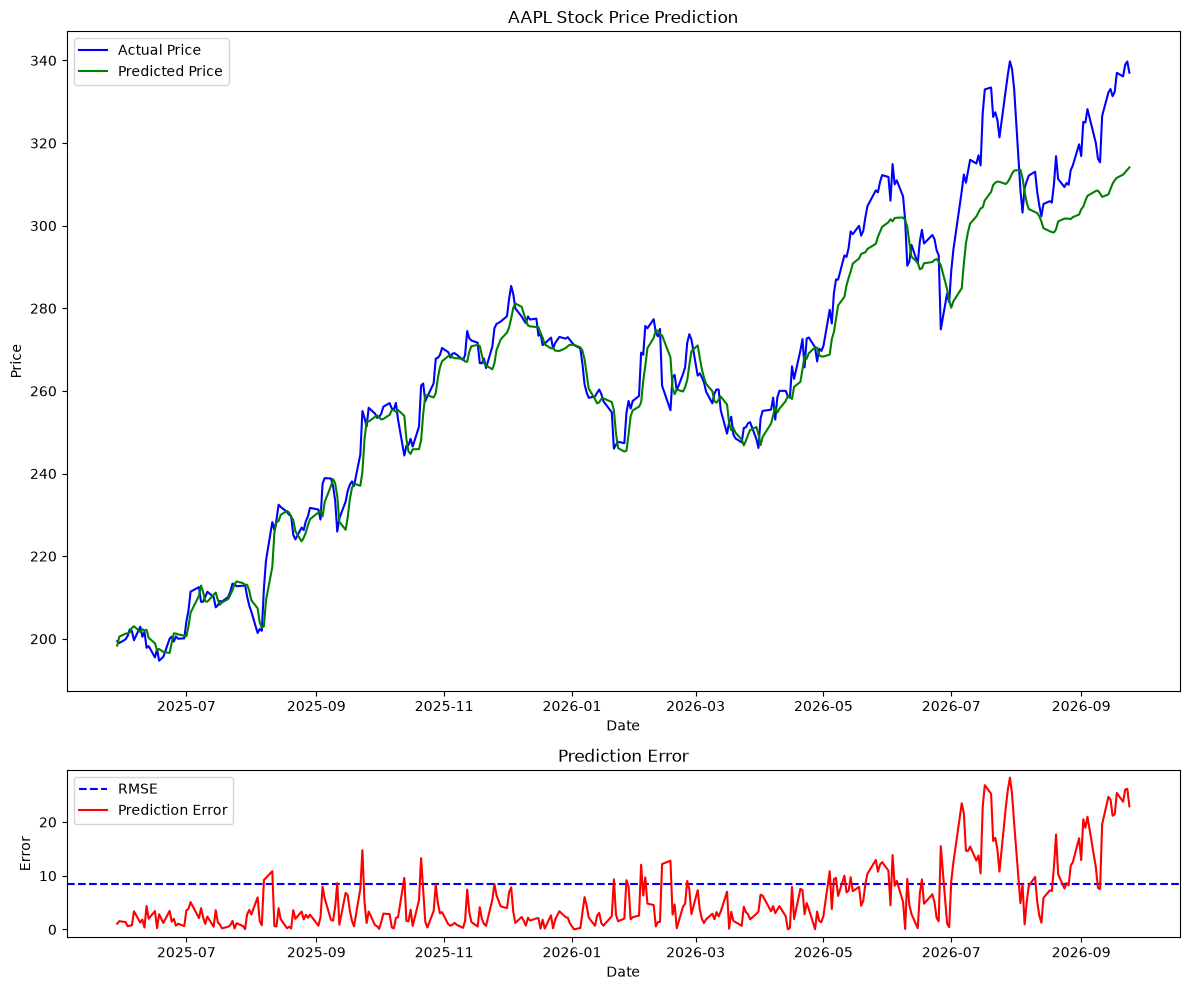

In [47]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

# --- Subplot 1: Actual vs Predicted Price (Top 3 rows) ---
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

# --- Subplot 2: Prediction Error (Bottom 1 row) ---
ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()